In [25]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# =========================================================
# 0. 데이터 불러오기
# =========================================================

# Parquet 파일인 경우
#df = pd.read_parquet("FAERS_2024_2026_PSSS_final.parquet")

df = pd.read_csv(
     "FAERS_2023_2026_PSSS_final.csv",
   dtype={"caseid": str, "primaryid": str},
  low_memory=False
)


# =========================================================
# 1. 기본 전처리
# =========================================================

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.lower()
)

required_cols = [
    "caseid",
    "primaryid",
    "prod_ai",
    "role_cod",
    "pt"
]

missing_cols = [
    col for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(f"필요한 컬럼이 없습니다: {missing_cols}")


# 문자열 정리
for col in required_cols:
    df[col] = df[col].astype("string").str.strip()


# 분석용 소문자 컬럼
df["prod_ai_normalized"] = (
    df["prod_ai"]
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

df["pt_normalized"] = (
    df["pt"]
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)


# primaryid 결측 제거
df = df[
    df["primaryid"].notna() &
    (df["primaryid"] != "")
].copy()


# 완전히 동일한 행 중복 제거
df = df.drop_duplicates(
    subset=[
        "primaryid",
        "prod_ai_normalized",
        "role_cod",
        "pt_normalized"
    ]
).copy()


print("전체 행 수:", f"{len(df):,}")
print("전체 고유 primaryid 수:", f"{df['primaryid'].nunique():,}")

전체 행 수: 50,906,205
전체 고유 primaryid 수: 4,565,982


In [26]:
# =========================================================
# 2. 약물별 검색 이름 설정
# =========================================================

drug_aliases = {
    "inclisiran": [
        "inclisiran",
        "inclisiran sodium"
    ],

    "evolocumab": [
        "evolocumab"
    ],

    "rosuvastatin": [
        "rosuvastatin",
        "rosuvastatin calcium"
    ]
}


# =========================================================
# 3. 약물별 고유 case 수 계산
# =========================================================

drug_case_counts = []

for drug_name, aliases in drug_aliases.items():

    drug_mask = df["prod_ai_normalized"].isin(aliases)

    drug_case_counts.append({
        "Drug": drug_name,
        "Case_Count_primaryid": df.loc[
            drug_mask,
            "primaryid"
        ].nunique(),

        "Row_Count": drug_mask.sum(),

        "PS_Case_Count": df.loc[
            drug_mask &
            (df["role_cod"].str.upper() == "PS"),
            "primaryid"
        ].nunique(),

        "SS_Case_Count": df.loc[
            drug_mask &
            (df["role_cod"].str.upper() == "SS"),
            "primaryid"
        ].nunique()
    })


drug_case_counts_df = pd.DataFrame(drug_case_counts)

print("\n약물별 고유 사례 수")
display(drug_case_counts_df)


약물별 고유 사례 수


,Drug,Case_Count_primaryid,Row_Count,PS_Case_Count,SS_Case_Count
0,inclisiran,6489,24593,6018,1708
1,evolocumab,58491,187902,57734,17586
2,rosuvastatin,13795,93630,7548,6906


In [27]:
# =========================================================
# 4. 분석 대상 이상사례
# =========================================================

target_pts = [
    "injection site pain",
    "injection site reaction",
    "muscle spasms",
    "myalgia",
    "dyspnoea",
    "rhabdomyolysis",
    "arthralgia",
    "drug ineffective",
    "hepatotoxicity",
    "blood pressure increased"
]


# 분석 대상 약물
analysis_drugs = {
    "inclisiran": drug_aliases["inclisiran"],
    "rosuvastatin": drug_aliases["rosuvastatin"]
}

In [28]:
# =========================================================
# 5. ROR, PRR 계산 함수
# =========================================================

def calculate_disproportionality(
    data,
    drug_name,
    drug_aliases,
    target_pt,
    correction=0.5
):
    """
    고유 primaryid 기준으로 A/B/C/D 및 ROR, PRR 계산

    A: 관심 약물 + 관심 이상사례
    B: 관심 약물 + 관심 이상사례 없음
    C: 관심 약물 없음 + 관심 이상사례
    D: 관심 약물 없음 + 관심 이상사례 없음
    """

    # 전체 분석 대상 사례
    all_cases = set(
        data["primaryid"]
        .dropna()
        .astype(str)
        .unique()
    )

    # 관심 약물이 보고된 사례
    drug_cases = set(
        data.loc[
            data["prod_ai_normalized"].isin(drug_aliases),
            "primaryid"
        ]
        .dropna()
        .astype(str)
        .unique()
    )

    # 관심 이상사례가 보고된 사례
    event_cases = set(
        data.loc[
            data["pt_normalized"] == target_pt.lower(),
            "primaryid"
        ]
        .dropna()
        .astype(str)
        .unique()
    )

    # -----------------------------------------------------
    # 2 × 2 table
    # -----------------------------------------------------

    A = len(drug_cases & event_cases)

    B = len(drug_cases - event_cases)

    C = len(event_cases - drug_cases)

    D = len(
        all_cases -
        drug_cases -
        event_cases
    )


    # -----------------------------------------------------
    # 원자료 기준 ROR, PRR
    # -----------------------------------------------------

    if B > 0 and C > 0:
        ror = (A * D) / (B * C)
    else:
        ror = np.nan


    if (
        (A + B) > 0 and
        (C + D) > 0 and
        C > 0
    ):
        prr = (
            A / (A + B)
        ) / (
            C / (C + D)
        )
    else:
        prr = np.nan


    # -----------------------------------------------------
    # ROR 95% CI
    # 0 cell이 있는 경우 Haldane-Anscombe correction 적용
    # -----------------------------------------------------

    corrected = any(x == 0 for x in [A, B, C, D])

    if corrected:
        A_ci = A + correction
        B_ci = B + correction
        C_ci = C + correction
        D_ci = D + correction
    else:
        A_ci = A
        B_ci = B
        C_ci = C
        D_ci = D


    ror_for_ci = (
        A_ci * D_ci
    ) / (
        B_ci * C_ci
    )

    se_log_ror = np.sqrt(
        (1 / A_ci) +
        (1 / B_ci) +
        (1 / C_ci) +
        (1 / D_ci)
    )

    ror_ci_lower = np.exp(
        np.log(ror_for_ci) -
        1.96 * se_log_ror
    )

    ror_ci_upper = np.exp(
        np.log(ror_for_ci) +
        1.96 * se_log_ror
    )


    # -----------------------------------------------------
    # Chi-square와 p-value
    # -----------------------------------------------------

    contingency_table = np.array([
        [A, B],
        [C, D]
    ])

    try:
        chi2, p_value, _, _ = chi2_contingency(
            contingency_table,
            correction=False
        )
    except ValueError:
        chi2 = np.nan
        p_value = np.nan


    # -----------------------------------------------------
    # Signal 기준
    # -----------------------------------------------------

    # 일반적인 ROR 기준:
    # A >= 3, ROR 95% CI lower > 1
    ror_signal = (
        A >= 3 and
        ror_ci_lower > 1
    )

    # Evans PRR 기준:
    # A >= 3, PRR >= 2, chi-square >= 4
    prr_signal = (
        A >= 3 and
        pd.notna(prr) and
        prr >= 2 and
        pd.notna(chi2) and
        chi2 >= 4
    )


    return {
        "Drug": drug_name,
        "PT": target_pt,

        "a_target_drug_event": A,
        "b_target_drug_other_event": B,
        "c_other_drug_event": C,
        "d_other_drug_other_event": D,

        "Drug_Case_Count": len(drug_cases),
        "Event_Case_Count": len(event_cases),
        "Total_Case_Count": len(all_cases),

        "ROR": ror,
        "ROR_95CI_Lower": ror_ci_lower,
        "ROR_95CI_Upper": ror_ci_upper,

        "PRR": prr,
        "Chi_square": chi2,
        "p_value": p_value,

        "ROR_signal": ror_signal,
        "PRR_signal": prr_signal,

        "Zero_Cell_Correction": corrected
    }

In [29]:
# =========================================================
# 6. 모든 약물 × 모든 PT 계산
# =========================================================

results = []

for drug_name, aliases in analysis_drugs.items():

    for target_pt in target_pts:

        result = calculate_disproportionality(
            data=df,
            drug_name=drug_name,
            drug_aliases=aliases,
            target_pt=target_pt
        )

        results.append(result)


signal_result_df = pd.DataFrame(results)

In [30]:
# =========================================================
# 7. 결과 정리
# =========================================================

numeric_cols = [
    "ROR",
    "ROR_95CI_Lower",
    "ROR_95CI_Upper",
    "PRR",
    "Chi_square",
    "p_value"
]

signal_result_df[numeric_cols] = (
    signal_result_df[numeric_cols]
    .round(4)
)


signal_result_df["Final_signal"] = np.select(
    [
        signal_result_df["ROR_signal"] &
        signal_result_df["PRR_signal"],

        signal_result_df["ROR_signal"] |
        signal_result_df["PRR_signal"]
    ],
    [
        "ROR + PRR signal",
        "One-method signal"
    ],
    default="No signal"
)


display_cols = [
    "Drug",
    "PT",

    "a_target_drug_event",
    "b_target_drug_other_event",
    "c_other_drug_event",
    "d_other_drug_other_event",

    "ROR",
    "ROR_95CI_Lower",
    "ROR_95CI_Upper",

    "PRR",
    "Chi_square",
    "p_value",

    "ROR_signal",
    "PRR_signal",
    "Final_signal"
]


print("\nInclisiran 및 Rosuvastatin ROR·PRR 결과")
display(
    signal_result_df[display_cols]
)


Inclisiran 및 Rosuvastatin ROR·PRR 결과


,Drug,PT,a_target_drug_event,b_target_drug_other_event,c_other_drug_event,d_other_drug_other_event,ROR,ROR_95CI_Lower,ROR_95CI_Upper,PRR,Chi_square,p_value,ROR_signal,PRR_signal,Final_signal
0,inclisiran,injection site pain,463,6026,81850,4477643,4.2032,3.8232,4.6211,3.9747,1043.7787,0.0000,True,True,ROR + PRR signal
1,inclisiran,injection site reaction,193,6296,12798,4546695,10.8905,9.4273,12.5807,10.5963,1657.0946,0.0000,True,True,ROR + PRR signal
2,inclisiran,muscle spasms,200,6289,35504,4523989,4.0522,3.5187,4.6666,3.9581,443.1458,0.0000,True,True,ROR + PRR signal
3,inclisiran,myalgia,523,5966,33095,4526398,11.9897,10.9574,13.1193,11.1040,4768.7790,0.0000,True,True,ROR + PRR signal
4,inclisiran,dyspnoea,276,6213,114987,4444506,1.7170,1.5218,1.9373,1.6865,78.9435,0.0000,True,False,One-method signal
5,inclisiran,rhabdomyolysis,7,6482,7783,4551710,0.6316,0.3009,1.3258,0.6320,1.5016,0.2204,False,False,No signal
6,inclisiran,arthralgia,686,5803,106378,4453115,4.9486,4.5710,5.3574,4.5312,1920.7251,0.0000,True,True,ROR + PRR signal
7,inclisiran,drug ineffective,353,6136,283757,4275736,0.8669,0.7786,0.9651,0.8741,6.8162,0.0090,False,False,No signal
8,inclisiran,hepatotoxicity,2,6487,5382,4554111,0.2609,0.0652,1.0436,0.2611,4.1852,0.0408,False,False,No signal
9,inclisiran,blood pressure increased,63,6426,34673,4524820,1.2794,0.9980,1.6401,1.2767,3.8001,0.0513,False,False,No signal


In [31]:
output_file = "inclisiran_rosuvastatin_ROR_PRR_2023_results.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    drug_case_counts_df.to_excel(
        writer,
        sheet_name="Drug_Case_Counts",
        index=False
    )

    signal_result_df.to_excel(
        writer,
        sheet_name="All_Results",
        index=False
    )

    inclisiran_result.to_excel(
        writer,
        sheet_name="Inclisiran",
        index=False
    )

    rosuvastatin_result.to_excel(
        writer,
        sheet_name="Rosuvastatin",
        index=False
    )


print(f"저장 완료: {output_file}")

저장 완료: inclisiran_rosuvastatin_ROR_PRR_2023_results.xlsx


In [32]:
# Inclisiran 결과
inclisiran_result = signal_result_df[
    signal_result_df["Drug"] == "inclisiran"
].copy()

display(inclisiran_result[display_cols])

,Drug,PT,a_target_drug_event,b_target_drug_other_event,c_other_drug_event,d_other_drug_other_event,ROR,ROR_95CI_Lower,ROR_95CI_Upper,PRR,Chi_square,p_value,ROR_signal,PRR_signal,Final_signal
0,inclisiran,injection site pain,463,6026,81850,4477643,4.2032,3.8232,4.6211,3.9747,1043.7787,0.0000,True,True,ROR + PRR signal
1,inclisiran,injection site reaction,193,6296,12798,4546695,10.8905,9.4273,12.5807,10.5963,1657.0946,0.0000,True,True,ROR + PRR signal
2,inclisiran,muscle spasms,200,6289,35504,4523989,4.0522,3.5187,4.6666,3.9581,443.1458,0.0000,True,True,ROR + PRR signal
3,inclisiran,myalgia,523,5966,33095,4526398,11.9897,10.9574,13.1193,11.1040,4768.7790,0.0000,True,True,ROR + PRR signal
4,inclisiran,dyspnoea,276,6213,114987,4444506,1.7170,1.5218,1.9373,1.6865,78.9435,0.0000,True,False,One-method signal
5,inclisiran,rhabdomyolysis,7,6482,7783,4551710,0.6316,0.3009,1.3258,0.6320,1.5016,0.2204,False,False,No signal
6,inclisiran,arthralgia,686,5803,106378,4453115,4.9486,4.5710,5.3574,4.5312,1920.7251,0.0000,True,True,ROR + PRR signal
7,inclisiran,drug ineffective,353,6136,283757,4275736,0.8669,0.7786,0.9651,0.8741,6.8162,0.0090,False,False,No signal
8,inclisiran,hepatotoxicity,2,6487,5382,4554111,0.2609,0.0652,1.0436,0.2611,4.1852,0.0408,False,False,No signal
9,inclisiran,blood pressure increased,63,6426,34673,4524820,1.2794,0.9980,1.6401,1.2767,3.8001,0.0513,False,False,No signal


In [33]:
# Rosuvastatin 결과
rosuvastatin_result = signal_result_df[
    signal_result_df["Drug"] == "rosuvastatin"
].copy()

display(rosuvastatin_result[display_cols])

,Drug,PT,a_target_drug_event,b_target_drug_other_event,c_other_drug_event,d_other_drug_other_event,ROR,ROR_95CI_Lower,ROR_95CI_Upper,PRR,Chi_square,p_value,ROR_signal,PRR_signal,Final_signal
10,rosuvastatin,injection site pain,84,13711,82229,4469958,0.3330,0.2687,0.4128,0.3371,111.4002,0.0000,False,False,No signal
11,rosuvastatin,injection site reaction,1,13794,12990,4539197,0.0253,0.0036,0.1799,0.0254,37.4942,0.0000,False,False,No signal
12,rosuvastatin,muscle spasms,753,13042,34951,4517236,7.4621,6.9284,8.0370,7.1094,3900.4283,0.0000,True,True,ROR + PRR signal
13,rosuvastatin,myalgia,1578,12217,32040,4520147,18.2223,17.2718,19.2250,16.2522,21686.5611,0.0000,True,True,ROR + PRR signal
14,rosuvastatin,dyspnoea,1533,12262,113730,4438457,4.8791,4.6253,5.1468,4.4480,4147.6507,0.0000,True,True,ROR + PRR signal
15,rosuvastatin,rhabdomyolysis,1091,12704,6699,4545488,58.2713,54.5323,62.2667,53.7419,48644.9239,0.0000,True,True,ROR + PRR signal
16,rosuvastatin,arthralgia,742,13053,106322,4445865,2.3770,2.2070,2.5601,2.3029,556.2189,0.0000,True,True,ROR + PRR signal
17,rosuvastatin,drug ineffective,889,12906,283221,4268966,1.0383,0.9699,1.1114,1.0358,1.1691,0.2796,False,False,No signal
18,rosuvastatin,hepatotoxicity,50,13745,5334,4546853,3.1009,2.3460,4.0987,3.0933,70.2519,0.0000,True,True,ROR + PRR signal
19,rosuvastatin,blood pressure increased,269,13526,34467,4517720,2.6067,2.3093,2.9425,2.5754,259.2001,0.0000,True,True,ROR + PRR signal


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 0. 파일 불러오기
# =========================================================

input_file = "inclisiran_rosuvastatin_ROR_PRR_results.xlsx"

result_df = pd.read_excel(
    input_file,
    sheet_name="All_Results"
)

print(result_df.columns.tolist())

['Drug', 'PT', 'a_target_drug_event', 'b_target_drug_other_event', 'c_other_drug_event', 'd_other_drug_other_event', 'Drug_Case_Count', 'Event_Case_Count', 'Total_Case_Count', 'ROR', 'ROR_95CI_Lower', 'ROR_95CI_Upper', 'PRR', 'Chi_square', 'p_value', 'ROR_signal', 'PRR_signal', 'Zero_Cell_Correction', 'Final_signal']


In [16]:
# =========================================================
# 1. 분석 대상 부작용 및 약물 설정
# =========================================================

target_pts = [
    "injection site pain",
    "injection site reaction",
    "muscle spasms",
    "myalgia",
    "dyspnoea",
    "rhabdomyolysis",
    "arthralgia",
    "drug ineffective",
    "hepatotoxicity",
    "blood pressure increased"
]

target_drugs = [
    "inclisiran",
    "rosuvastatin"
]


# 문자열 정리
result_df["Drug"] = (
    result_df["Drug"]
    .astype(str)
    .str.strip()
    .str.lower()
)

result_df["PT"] = (
    result_df["PT"]
    .astype(str)
    .str.strip()
    .str.lower()
)


# 필요한 약물과 PT만 선택
forest_df = result_df[
    result_df["Drug"].isin(target_drugs) &
    result_df["PT"].isin(target_pts)
].copy()


# 사용자가 지정한 PT 순서 유지
forest_df["PT"] = pd.Categorical(
    forest_df["PT"],
    categories=target_pts,
    ordered=True
)

forest_df = forest_df.sort_values(
    ["PT", "Drug"]
).reset_index(drop=True)

display(
    forest_df[
        [
            "Drug",
            "PT",
            "ROR",
            "ROR_95CI_Lower",
            "ROR_95CI_Upper",
            "ROR_signal"
        ]
    ]
)

,Drug,PT,ROR,ROR_95CI_Lower,ROR_95CI_Upper,ROR_signal
0,inclisiran,injection site pain,2.4843,2.1602,2.8570,True
1,rosuvastatin,injection site pain,0.2363,0.1774,0.3148,False
2,inclisiran,injection site reaction,11.9658,10.1707,14.0778,True
3,rosuvastatin,injection site reaction,0.0000,0.0010,0.2606,False
4,inclisiran,muscle spasms,3.6372,3.0411,4.3501,True
5,rosuvastatin,muscle spasms,7.3060,6.6946,7.9733,True
6,inclisiran,myalgia,11.7600,10.5427,13.1178,True
7,rosuvastatin,myalgia,18.2567,17.1509,19.4338,True
8,inclisiran,dyspnoea,1.3888,1.1835,1.6297,True
9,rosuvastatin,dyspnoea,4.8958,4.6008,5.2098,True


ValueError: 'xerr' must not contain negative values

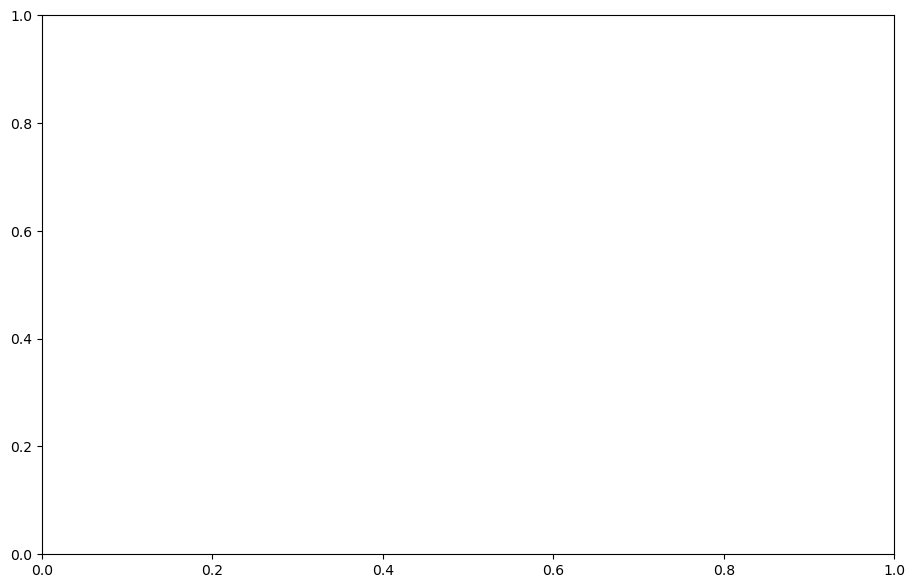

In [17]:
# =========================================================
# 2. Inclisiran + Rosuvastatin Forest plot
# =========================================================

# 약물별 데이터 분리
inclisiran_df = (
    forest_df[
        forest_df["Drug"] == "inclisiran"
    ]
    .set_index("PT")
    .reindex(target_pts)
)

rosuvastatin_df = (
    forest_df[
        forest_df["Drug"] == "rosuvastatin"
    ]
    .set_index("PT")
    .reindex(target_pts)
)


# ---------------------------------------------------------
# 그래프 위치 설정
# ---------------------------------------------------------

y = np.arange(len(target_pts))

# 같은 PT에서 두 약물이 겹치지 않도록 위아래로 이동
offset = 0.16

y_inclisiran = y + offset
y_rosuvastatin = y - offset


# ---------------------------------------------------------
# 그래프 생성
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 7)
)


# Inclisiran
ax.errorbar(
    inclisiran_df["ROR"],
    y_inclisiran,
    xerr=[
        inclisiran_df["ROR"] -
        inclisiran_df["ROR_95CI_Lower"],

        inclisiran_df["ROR_95CI_Upper"] -
        inclisiran_df["ROR"]
    ],
    fmt="o",
    markersize=7,
    capsize=4,
    linewidth=1.5,
    label="Inclisiran"
)


# Rosuvastatin
ax.errorbar(
    rosuvastatin_df["ROR"],
    y_rosuvastatin,
    xerr=[
        rosuvastatin_df["ROR"] -
        rosuvastatin_df["ROR_95CI_Lower"],

        rosuvastatin_df["ROR_95CI_Upper"] -
        rosuvastatin_df["ROR"]
    ],
    fmt="s",
    markersize=7,
    capsize=4,
    linewidth=1.5,
    label="Rosuvastatin"
)


# ---------------------------------------------------------
# 기준선
# ---------------------------------------------------------

ax.axvline(
    x=1,
    linestyle="--",
    linewidth=1.2,
    label="ROR = 1"
)


# ROR는 비율이므로 로그 스케일 권장
ax.set_xscale("log")


# ---------------------------------------------------------
# 축 및 제목
# ---------------------------------------------------------

ax.set_yticks(y)

ax.set_yticklabels(
    [
        pt.replace("_", " ").title()
        for pt in target_pts
    ]
)

# 첫 번째 PT가 위에 오도록 순서 뒤집기
ax.invert_yaxis()

ax.set_xlabel(
    "Reporting Odds Ratio (ROR), log scale"
)

ax.set_ylabel(
    "Adverse Event"
)

ax.set_title(
    "Comparison of Adverse Event Reporting Odds Ratios\n"
    "Inclisiran vs Rosuvastatin"
)

ax.grid(
    axis="x",
    linestyle=":",
    alpha=0.5
)

ax.legend(
    loc="best"
)

plt.tight_layout()


# ---------------------------------------------------------
# 저장
# ---------------------------------------------------------

plt.savefig(
    "forest_plot_inclisiran_rosuvastatin_ROR.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "forest_plot_inclisiran_rosuvastatin_ROR.pdf",
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 3. ROR와 95% CI 수치 표시
# =========================================================

for i, pt in enumerate(target_pts):

    # Inclisiran
    if pt in inclisiran_df.index:

        row = inclisiran_df.loc[pt]

        ax.annotate(
            f'{row["ROR"]:.2f} '
            f'({row["ROR_95CI_Lower"]:.2f}–'
            f'{row["ROR_95CI_Upper"]:.2f})',

            xy=(
                row["ROR_95CI_Upper"],
                y_inclisiran[i]
            ),

            xytext=(6, 0),
            textcoords="offset points",
            va="center",
            fontsize=8
        )


    # Rosuvastatin
    if pt in rosuvastatin_df.index:

        row = rosuvastatin_df.loc[pt]

        ax.annotate(
            f'{row["ROR"]:.2f} '
            f'({row["ROR_95CI_Lower"]:.2f}–'
            f'{row["ROR_95CI_Upper"]:.2f})',

            xy=(
                row["ROR_95CI_Upper"],
                y_rosuvastatin[i]
            ),

            xytext=(6, 0),
            textcoords="offset points",
            va="center",
            fontsize=8
        )

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 0. 결과 파일 불러오기
# =========================================================

input_file = "inclisiran_rosuvastatin_ROR_PRR_results.xlsx"

result_df = pd.read_excel(
    input_file,
    sheet_name="All_Results"
)

# 문자열 정리
result_df["Drug"] = (
    result_df["Drug"]
    .astype(str)
    .str.strip()
    .str.lower()
)

result_df["PT"] = (
    result_df["PT"]
    .astype(str)
    .str.strip()
    .str.lower()
)

In [19]:
# =========================================================
# 1. ROR와 95% CI 재계산 함수
# =========================================================

def recalculate_ror_ci(row):
    """
    A/B/C/D 중 하나라도 0이면 모든 셀에 0.5를 더하는
    Haldane-Anscombe correction 적용
    """

    a = float(row["a_target_drug_event"])
    b = float(row["b_target_drug_other_event"])
    c = float(row["c_other_drug_event"])
    d = float(row["d_other_drug_other_event"])

    zero_correction = any(value == 0 for value in [a, b, c, d])

    if zero_correction:
        a += 0.5
        b += 0.5
        c += 0.5
        d += 0.5

    ror = (a * d) / (b * c)

    standard_error = np.sqrt(
        (1 / a) +
        (1 / b) +
        (1 / c) +
        (1 / d)
    )

    ci_lower = np.exp(
        np.log(ror) - 1.96 * standard_error
    )

    ci_upper = np.exp(
        np.log(ror) + 1.96 * standard_error
    )

    return pd.Series({
        "ROR_plot": ror,
        "ROR_lower_plot": ci_lower,
        "ROR_upper_plot": ci_upper,
        "Zero_correction_plot": zero_correction
    })


recalculated = result_df.apply(
    recalculate_ror_ci,
    axis=1
)

result_df = pd.concat(
    [result_df, recalculated],
    axis=1
)

In [20]:
# =========================================================
# 2. 분석 대상 설정
# =========================================================

target_pts = [
    "injection site pain",
    "injection site reaction",
    "muscle spasms",
    "myalgia",
    "dyspnoea",
    "rhabdomyolysis",
    "arthralgia",
    "drug ineffective",
    "hepatotoxicity",
    "blood pressure increased"
]

target_drugs = [
    "inclisiran",
    "rosuvastatin"
]


forest_df = result_df[
    result_df["Drug"].isin(target_drugs) &
    result_df["PT"].isin(target_pts)
].copy()


# PT 순서 지정
forest_df["PT"] = pd.Categorical(
    forest_df["PT"],
    categories=target_pts,
    ordered=True
)

forest_df = forest_df.sort_values(
    ["PT", "Drug"]
)

In [21]:
# =========================================================
# 3. 약물별 데이터 정렬
# =========================================================

inclisiran_df = (
    forest_df[
        forest_df["Drug"] == "inclisiran"
    ]
    .set_index("PT")
    .reindex(target_pts)
)

rosuvastatin_df = (
    forest_df[
        forest_df["Drug"] == "rosuvastatin"
    ]
    .set_index("PT")
    .reindex(target_pts)
)


# 숫자형 변환
plot_columns = [
    "ROR_plot",
    "ROR_lower_plot",
    "ROR_upper_plot"
]

for col in plot_columns:
    inclisiran_df[col] = pd.to_numeric(
        inclisiran_df[col],
        errors="coerce"
    )

    rosuvastatin_df[col] = pd.to_numeric(
        rosuvastatin_df[col],
        errors="coerce"
    )

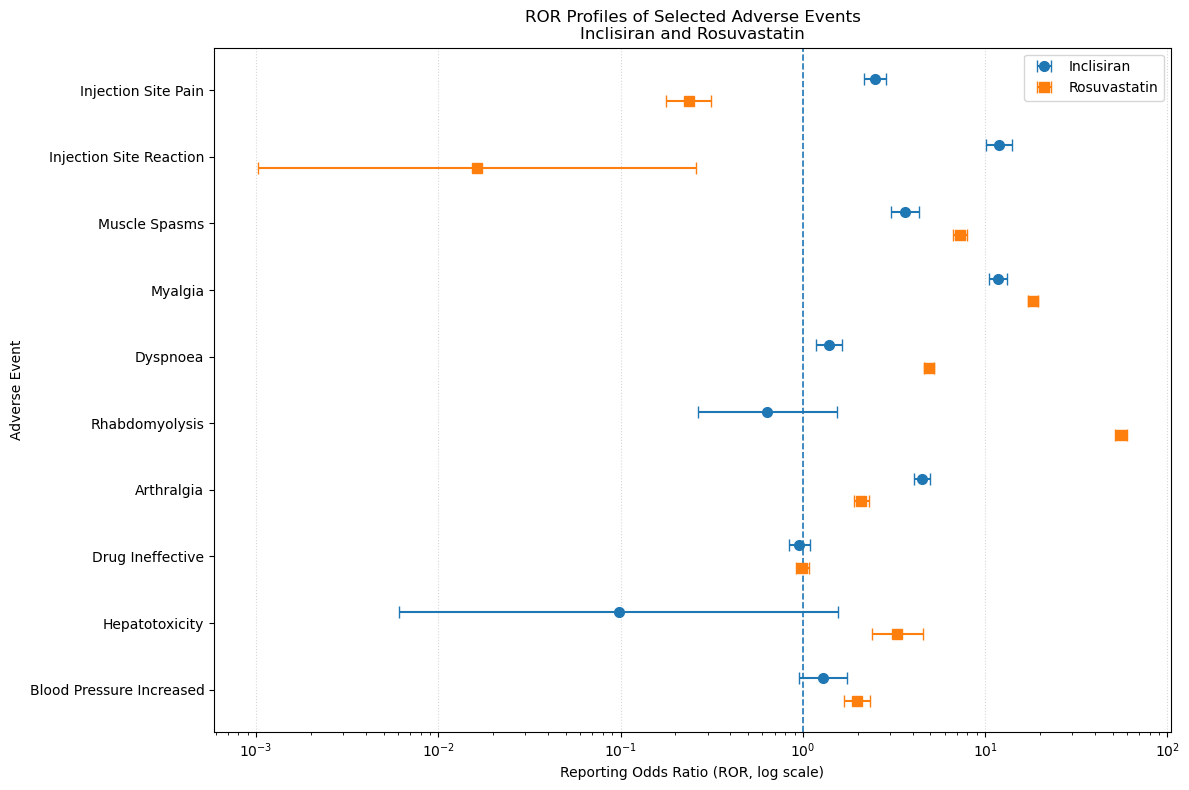

In [22]:
# =========================================================
# 4. Forest plot
# =========================================================

y = np.arange(len(target_pts))

offset = 0.17

y_inclisiran = y - offset
y_rosuvastatin = y + offset


fig, ax = plt.subplots(
    figsize=(12, 8)
)


# ---------------------------------------------------------
# Inclisiran 오차 범위
# ---------------------------------------------------------

inclisiran_lower_error = (
    inclisiran_df["ROR_plot"] -
    inclisiran_df["ROR_lower_plot"]
).clip(lower=0)

inclisiran_upper_error = (
    inclisiran_df["ROR_upper_plot"] -
    inclisiran_df["ROR_plot"]
).clip(lower=0)


ax.errorbar(
    x=inclisiran_df["ROR_plot"],
    y=y_inclisiran,
    xerr=np.vstack([
        inclisiran_lower_error,
        inclisiran_upper_error
    ]),
    fmt="o",
    markersize=7,
    capsize=4,
    elinewidth=1.5,
    label="Inclisiran"
)


# ---------------------------------------------------------
# Rosuvastatin 오차 범위
# ---------------------------------------------------------

rosuvastatin_lower_error = (
    rosuvastatin_df["ROR_plot"] -
    rosuvastatin_df["ROR_lower_plot"]
).clip(lower=0)

rosuvastatin_upper_error = (
    rosuvastatin_df["ROR_upper_plot"] -
    rosuvastatin_df["ROR_plot"]
).clip(lower=0)


ax.errorbar(
    x=rosuvastatin_df["ROR_plot"],
    y=y_rosuvastatin,
    xerr=np.vstack([
        rosuvastatin_lower_error,
        rosuvastatin_upper_error
    ]),
    fmt="s",
    markersize=7,
    capsize=4,
    elinewidth=1.5,
    label="Rosuvastatin"
)


# ---------------------------------------------------------
# 기준선
# ---------------------------------------------------------

ax.axvline(
    x=1,
    linestyle="--",
    linewidth=1.2
)


# ROR는 로그 스케일
ax.set_xscale("log")


# ---------------------------------------------------------
# 축 설정
# ---------------------------------------------------------

ax.set_yticks(y)

ax.set_yticklabels(
    [
        pt.title()
        for pt in target_pts
    ]
)

ax.invert_yaxis()

ax.set_xlabel(
    "Reporting Odds Ratio (ROR, log scale)"
)

ax.set_ylabel(
    "Adverse Event"
)

ax.set_title(
    "ROR Profiles of Selected Adverse Events\n"
    "Inclisiran and Rosuvastatin"
)

ax.grid(
    axis="x",
    linestyle=":",
    alpha=0.5
)

ax.legend()

plt.tight_layout()


# ---------------------------------------------------------
# 저장
# ---------------------------------------------------------

plt.savefig(
    "forest_plot_inclisiran_rosuvastatin_ROR.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "forest_plot_inclisiran_rosuvastatin_ROR.pdf",
    bbox_inches="tight"
)

plt.show()

In [23]:
target_pts = [
    "muscle spasms",
    "myalgia",
    "rhabdomyolysis",
    "arthralgia",
    "hepatotoxicity"
]

In [ ]:
############## 새로운 시각화 ##############3

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# =========================================================
# 0. 파일 및 기본 설정
# =========================================================

input_file = "inclisiran_rosuvastatin_ROR_PRR_2023_results.xlsx"
sheet_name = "All_Results"

output_dir = Path("ROR_PRR_comparison_plots_without")
output_dir.mkdir(exist_ok=True)


# 비교할 약물
target_drugs = [
    "inclisiran",
    "rosuvastatin"
]


# 표시할 부작용 순서
target_pts = [
    "injection site pain",
    "injection site reaction",
    "muscle spasms",
    "myalgia",
    "dyspnoea",
    "rhabdomyolysis",
    "arthralgia",
    "drug ineffective",
    "hepatotoxicity",
    "blood pressure increased"
]


# =========================================================
# 1. 데이터 불러오기
# =========================================================

df = pd.read_excel(
    input_file,
    sheet_name=sheet_name
)


# 문자열 정리
df["Drug"] = (
    df["Drug"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["PT"] = (
    df["PT"]
    .astype(str)
    .str.strip()
    .str.lower()
)


# ROR, PRR 숫자형 변환
df["ROR"] = pd.to_numeric(
    df["ROR"],
    errors="coerce"
)

df["PRR"] = pd.to_numeric(
    df["PRR"],
    errors="coerce"
)


# 원하는 약물 및 PT만 선택
plot_df = df[
    df["Drug"].isin(target_drugs) &
    df["PT"].isin(target_pts)
].copy()


print("분석 대상 행 수:", len(plot_df))

display(
    plot_df[
        [
            "Drug",
            "PT",
            "ROR",
            "PRR",
            "ROR_signal",
            "PRR_signal"
        ]
    ]
)

분석 대상 행 수: 20


,Drug,PT,ROR,PRR,ROR_signal,PRR_signal
0,inclisiran,injection site pain,4.2032,3.9747,True,True
1,inclisiran,injection site reaction,10.8905,10.5963,True,True
2,inclisiran,muscle spasms,4.0522,3.9581,True,True
3,inclisiran,myalgia,11.9897,11.1040,True,True
4,inclisiran,dyspnoea,1.7170,1.6865,True,False
5,inclisiran,rhabdomyolysis,0.6316,0.6320,False,False
6,inclisiran,arthralgia,4.9486,4.5312,True,True
7,inclisiran,drug ineffective,0.8669,0.8741,False,False
8,inclisiran,hepatotoxicity,0.2609,0.2611,False,False
9,inclisiran,blood pressure increased,1.2794,1.2767,False,False


In [45]:
# =========================================================
# Dumbbell plot (ROR + PRR)
# =========================================================

def draw_dumbbell_plot(
    data,
    pt_order,
    output_path,
    title=None
):

    # -----------------------------
    # Wide format
    # -----------------------------
    ror = (
        data.pivot_table(
            index="PT",
            columns="Drug",
            values="ROR",
            aggfunc="first"
        )
        .reindex(pt_order)
    )

    prr = (
        data.pivot_table(
            index="PT",
            columns="Drug",
            values="PRR",
            aggfunc="first"
        )
        .reindex(pt_order)
    )

    y = np.arange(len(ror))

    fig, ax = plt.subplots(figsize=(13,8))

    # ===========================
    # ROR 연결선
    # ===========================

    for i in range(len(ror)):

        if pd.notna(ror.iloc[i]["inclisiran"]) and pd.notna(ror.iloc[i]["rosuvastatin"]):

            ax.plot(
                [ror.iloc[i]["inclisiran"],
                 ror.iloc[i]["rosuvastatin"]],
                [i,i],
                color="lightgray",
                linewidth=2,
                zorder=1
            )

    # ===========================
    # ROR
    # ===========================

    ax.scatter(
        ror["inclisiran"],
        y,
        color="#2E86AB",
        s=90,
        marker="o",
        label="Inclisiran (ROR)",
        zorder=3
    )

    ax.scatter(
        ror["rosuvastatin"],
        y,
        color="#E76F51",
        s=90,
        marker="o",
        label="Rosuvastatin (ROR)",
        zorder=3
    )

    # ===========================
    # PRR (조금 위)
    # ===========================

    offset = 0.18

    ax.scatter(
        prr["inclisiran"],
        y-offset,
        color="#2E86AB",
        s=90,
        marker="^",
        label="Inclisiran (PRR)",
        zorder=4
    )

    ax.scatter(
        prr["rosuvastatin"],
        y+offset,
        color="#E76F51",
        s=90,
        marker="^",
        label="Rosuvastatin (PRR)",
        zorder=4
    )

    # ===========================
    # 값 표시
    # ===========================

    xmax = np.nanmax([
        ror.max().max(),
        prr.max().max()
    ])

    txt = xmax*0.015

    for i in range(len(ror)):

        if pd.notna(ror.iloc[i]["inclisiran"]):
            ax.text(
                ror.iloc[i]["inclisiran"]-txt,
                i,
                f'{ror.iloc[i]["inclisiran"]:.2f}',
                fontsize=8,
                ha="right",
                va="center",
                color="#2E86AB"
            )

        if pd.notna(ror.iloc[i]["rosuvastatin"]):
            ax.text(
                ror.iloc[i]["rosuvastatin"]+txt,
                i,
                f'{ror.iloc[i]["rosuvastatin"]:.2f}',
                fontsize=8,
                ha="left",
                va="center",
                color="#E76F51"
            )

        if pd.notna(prr.iloc[i]["inclisiran"]):
            ax.text(
                prr.iloc[i]["inclisiran"]-txt,
                i-offset,
                f'{prr.iloc[i]["inclisiran"]:.2f}',
                fontsize=8,
                ha="right",
                va="center",
                color="#2E86AB"
            )

        if pd.notna(prr.iloc[i]["rosuvastatin"]):
            ax.text(
                prr.iloc[i]["rosuvastatin"]+txt,
                i+offset,
                f'{prr.iloc[i]["rosuvastatin"]:.2f}',
                fontsize=8,
                ha="left",
                va="center",
                color="#E76F51"
            )

    # ===========================
    # 축
    # ===========================

    ax.set_yticks(y)

    ax.set_yticklabels(
        [i.title() for i in pt_order]
    )

    ax.invert_yaxis()

    ax.set_xlabel("Disproportionality Measure")

    if title is None:
        title="Comparison of ROR and PRR"

    ax.set_title(title)

    ax.grid(axis="x", linestyle=":")

    ax.legend(frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

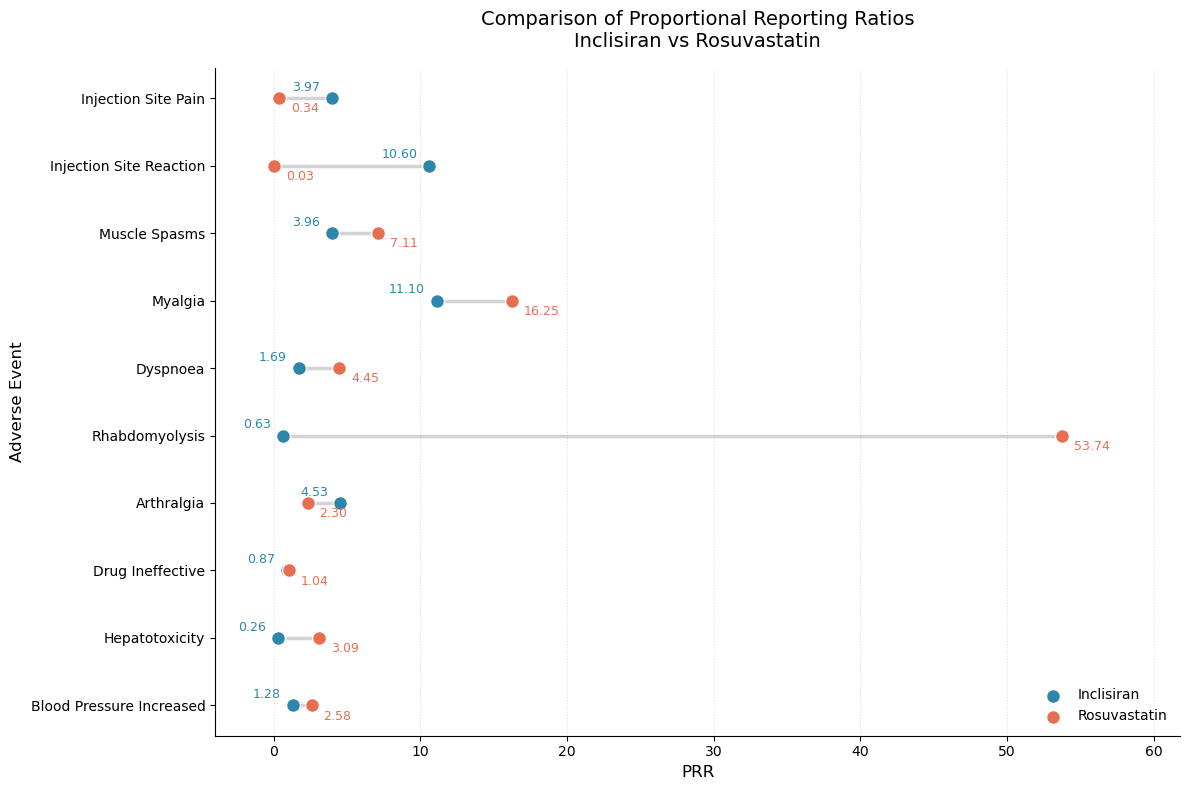

In [41]:
draw_dumbbell_plot(
    data=plot_df,
    metric="PRR",
    pt_order=target_pts,
    output_path=output_dir / "02_PRR_dumbbell_plot.png",
    title=(
        "Comparison of Proportional Reporting Ratios\n"
        "Inclisiran vs Rosuvastatin"
    )
)

In [42]:
# =========================================================
# 3. Cleveland dot plot 함수
# =========================================================

def draw_cleveland_plot(
    data,
    metric,
    pt_order,
    output_path,
    title=None
):
    """
    Inclisiran과 Rosuvastatin의 ROR 또는 PRR을
    Cleveland dot plot으로 비교한다.
    """

    # -----------------------------------------------------
    # 약물을 열로 변환
    # -----------------------------------------------------

    wide_df = (
        data
        .pivot_table(
            index="PT",
            columns="Drug",
            values=metric,
            aggfunc="first"
        )
        .reindex(pt_order)
    )


    wide_df = wide_df.dropna(
        how="all",
        subset=["inclisiran", "rosuvastatin"]
    )


    # 그래프 위치
    y = np.arange(len(wide_df))

    offset = 0.13

    y_inclisiran = y - offset
    y_rosuvastatin = y + offset


    # -----------------------------------------------------
    # 그래프 생성
    # -----------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(12, 8)
    )


    # 각 PT별 가이드선
    for position in y:

        ax.axhline(
            y=position,
            color="lightgray",
            linewidth=0.8,
            linestyle=":",
            zorder=0
        )


    # Inclisiran 점
    ax.scatter(
        wide_df["inclisiran"],
        y_inclisiran,
        s=95,
        color="#2E86AB",
        marker="o",
        label="Inclisiran",
        zorder=3
    )


    # Rosuvastatin 점
    ax.scatter(
        wide_df["rosuvastatin"],
        y_rosuvastatin,
        s=95,
        color="#E76F51",
        marker="s",
        label="Rosuvastatin",
        zorder=3
    )


    # -----------------------------------------------------
    # 실제 값 표시
    # -----------------------------------------------------

    max_value = np.nanmax(
        wide_df[
            ["inclisiran", "rosuvastatin"]
        ].to_numpy()
    )

    text_offset = max_value * 0.015


    for i, (_, row) in enumerate(wide_df.iterrows()):

        inclisiran_value = row["inclisiran"]
        rosuvastatin_value = row["rosuvastatin"]

        if pd.notna(inclisiran_value):

            ax.text(
                inclisiran_value + text_offset,
                y_inclisiran[i],
                f"{inclisiran_value:.2f}",
                va="center",
                ha="left",
                fontsize=9,
                color="#2E86AB"
            )

        if pd.notna(rosuvastatin_value):

            ax.text(
                rosuvastatin_value + text_offset,
                y_rosuvastatin[i],
                f"{rosuvastatin_value:.2f}",
                va="center",
                ha="left",
                fontsize=9,
                color="#E76F51"
            )


    # -----------------------------------------------------
    # 기준선
    # -----------------------------------------------------

    # ax.axvline(
    #     x=1,
    #     color="black",
    #     linestyle="--",
    #     linewidth=1.2,
    #     alpha=0.8,
    #     label=f"{metric} = 1"
    # )


    # -----------------------------------------------------
    # 축과 제목
    # -----------------------------------------------------

    ax.set_yticks(y)

    ax.set_yticklabels(
        [
            str(pt).title()
            for pt in wide_df.index
        ]
    )

    ax.invert_yaxis()

    ax.set_xlabel(
        metric,
        fontsize=12
    )

    ax.set_ylabel(
        "Adverse Event",
        fontsize=12
    )

    if title is None:
        title = (
            f"{metric} Cleveland Dot Plot\n"
            f"Inclisiran vs Rosuvastatin"
        )

    ax.set_title(
        title,
        fontsize=14,
        pad=15
    )


    ax.set_xlim(
        left=min(-0.2, np.nanmin(wide_df.to_numpy()) - text_offset * 5),
        right=max_value * 1.15
    )


    ax.grid(
        axis="x",
        linestyle=":",
        alpha=0.35
    )

    ax.legend(
        frameon=False,
        loc="lower right"
    )


    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

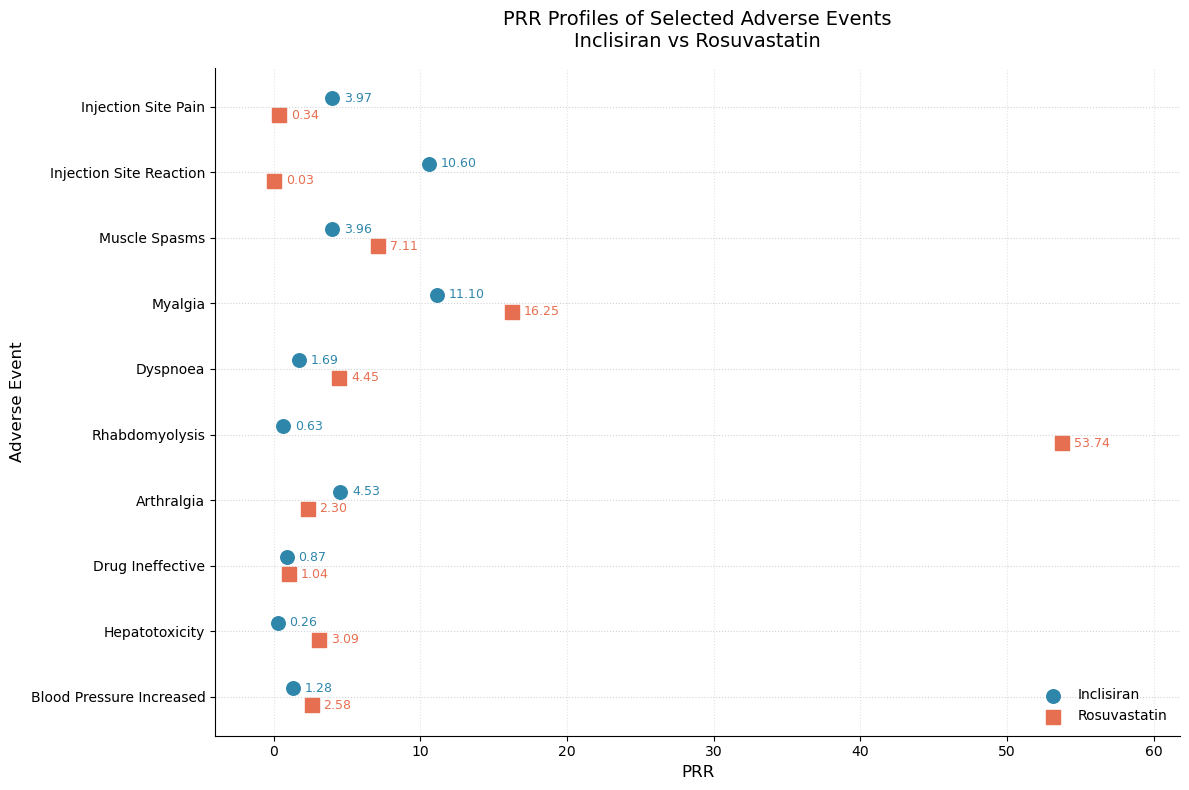

In [43]:
draw_cleveland_plot(
    data=plot_df,
    metric="PRR",
    pt_order=target_pts,
    output_path=output_dir / "04_PRR_cleveland_dot_plot.png",
    title=(
        "PRR Profiles of Selected Adverse Events\n"
        "Inclisiran vs Rosuvastatin"
    )
)

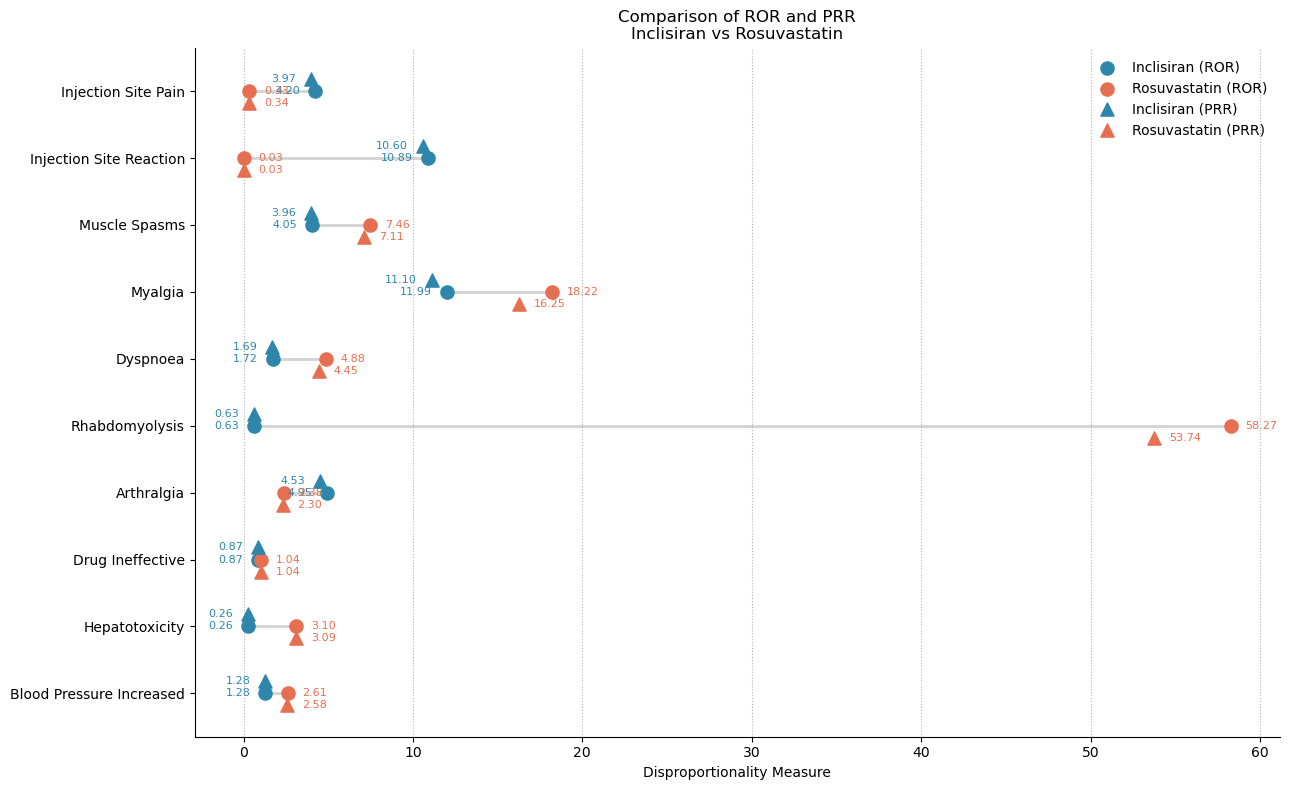

In [46]:
draw_dumbbell_plot(
    data=plot_df,
    pt_order=target_pts,
    output_path=output_dir/"ROR_PRR_Dumbbell.png",
    title="Comparison of ROR and PRR\nInclisiran vs Rosuvastatin"
)

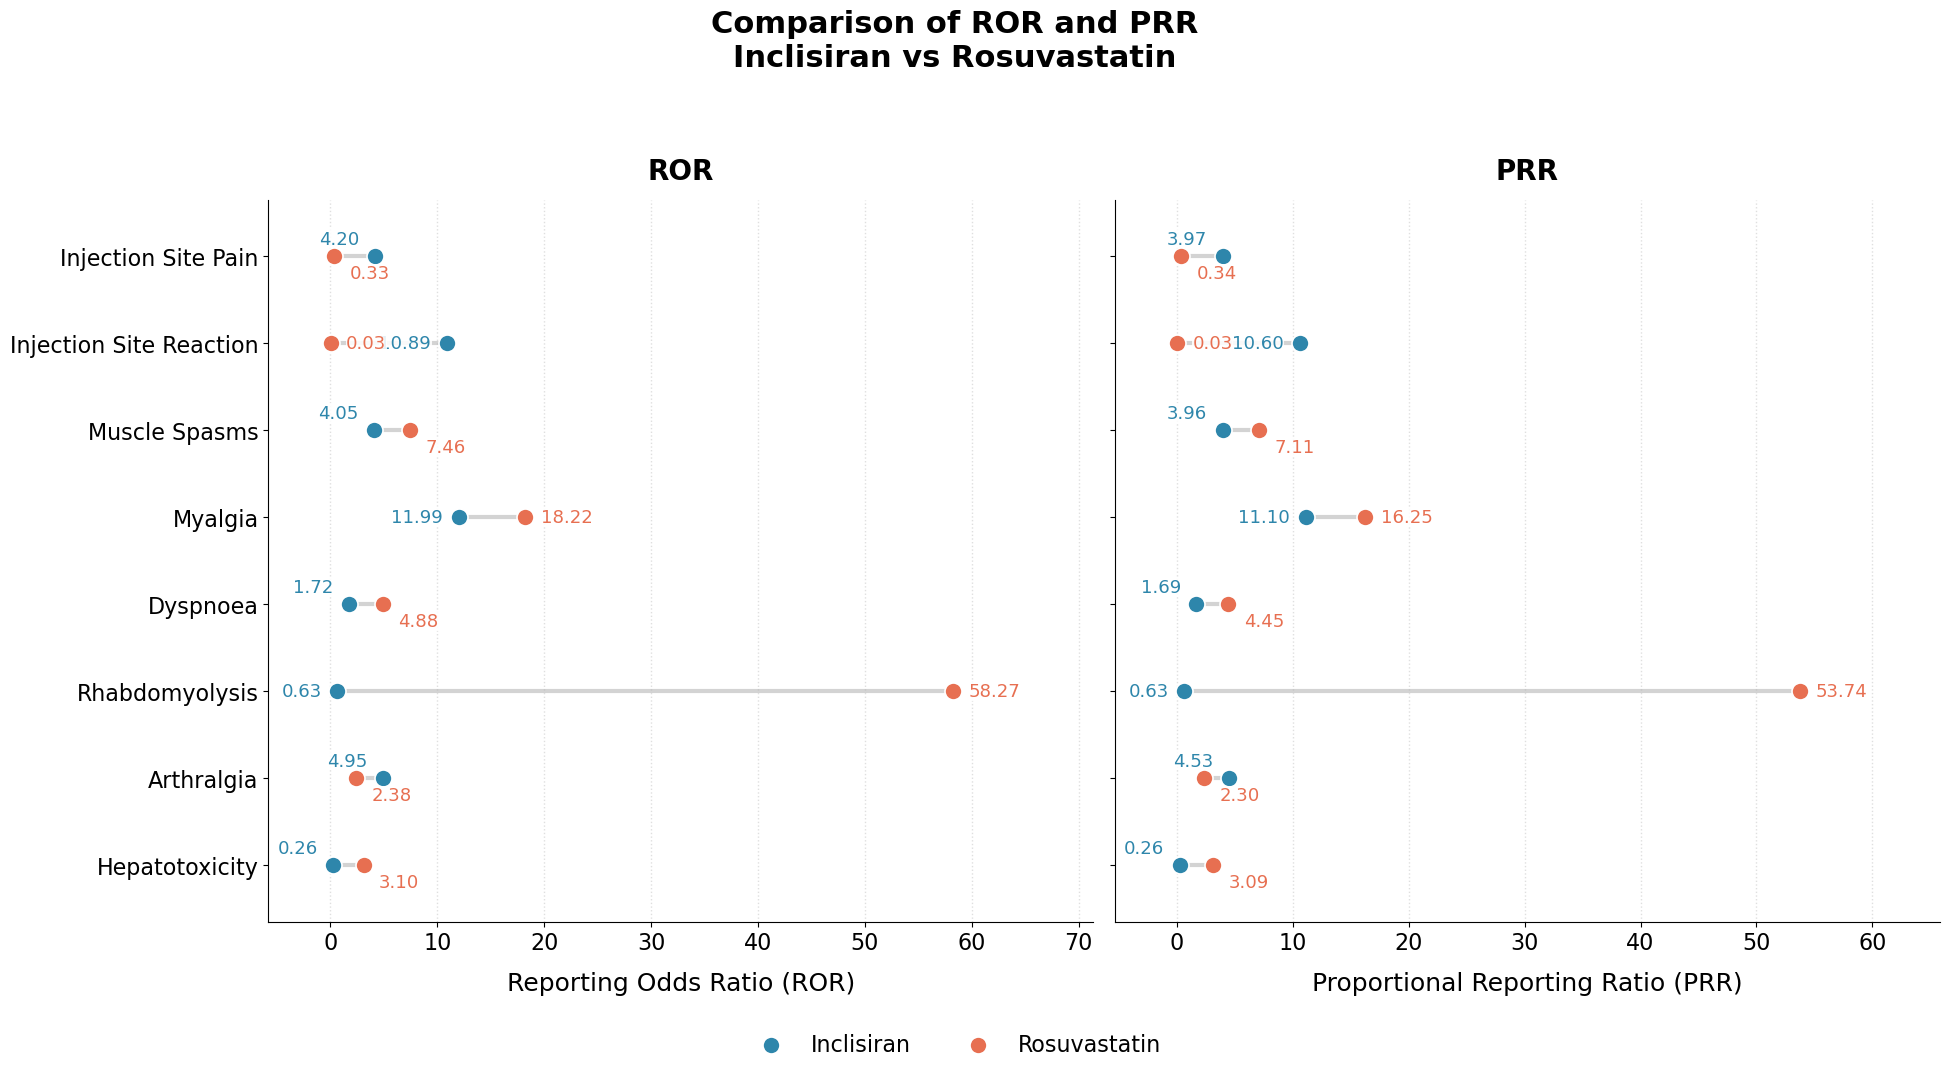

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# =========================================================
# 0. 파일 및 기본 설정
# =========================================================

input_file = "inclisiran_rosuvastatin_ROR_PRR_2023_results.xlsx"
sheet_name = "All_Results"

output_dir = Path("ROR_PRR_comparison_plots")
output_dir.mkdir(exist_ok=True)

output_path = output_dir / "Twin_Dumbbell_ROR_PRR.png"


target_drugs = [
    "inclisiran",
    "rosuvastatin"
]


target_pts = [
    "injection site pain",
    "injection site reaction",
    "muscle spasms",
    "myalgia",
    "dyspnoea",
    "rhabdomyolysis",
    "arthralgia",
    "hepatotoxicity"
]


# =========================================================
# 1. 글씨 크기 설정 ~ 크게크게
# =========================================================

TITLE_SIZE = 22
SUBTITLE_SIZE = 20
LABEL_SIZE = 18
TICK_SIZE = 16
VALUE_SIZE = 13
LEGEND_SIZE = 16

# 숫자가 가까울 때 위아래로 벌리는 정도
TEXT_VERTICAL_OFFSET = 0.20

# 두 값의 차이가 이 값보다 작으면 숫자를 위아래로 벌림
CLOSE_THRESHOLD_RATIO = 0.07

# =========================================================
# 2. 데이터 불러오기
# =========================================================

df = pd.read_excel(
    input_file,
    sheet_name=sheet_name
)


df["Drug"] = (
    df["Drug"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["PT"] = (
    df["PT"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["ROR"] = pd.to_numeric(
    df["ROR"],
    errors="coerce"
)

df["PRR"] = pd.to_numeric(
    df["PRR"],
    errors="coerce"
)


plot_df = df[
    df["Drug"].isin(target_drugs) &
    df["PT"].isin(target_pts)
].copy()

##################3
#####################################################

# =========================================================
# 3. 값 표시 함수
# =========================================================

def add_value_labels(
    ax,
    value_1,
    value_2,
    y_position,
    x_offset,
    axis_max,
    color_1="#2E86AB",
    color_2="#E76F51"
):
    """
    두 값이 가까우면 숫자 라벨을 위아래로 벌려서 표시.
    숫자 뒤에는 흰색 배경을 적용.
    """

    # 기본 y 위치
    y_1 = y_position
    y_2 = y_position

    # 두 값이 모두 존재하는 경우에만 거리 확인
    if pd.notna(value_1) and pd.notna(value_2):

        difference = abs(value_1 - value_2)

        # 축 전체 범위 대비 가까운 정도 판단
        close_threshold = axis_max * CLOSE_THRESHOLD_RATIO

        if difference < close_threshold:
            y_1 = y_position - TEXT_VERTICAL_OFFSET
            y_2 = y_position + TEXT_VERTICAL_OFFSET

    label_box = dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.88,
        pad=0.25
    )

    if pd.notna(value_1):

        ax.text(
            value_1 - x_offset,
            y_1,
            f"{value_1:.2f}",
            ha="right",
            va="center",
            fontsize=VALUE_SIZE,
            color=color_1,
            fontweight="medium",
            bbox=label_box,
            zorder=5
        )

    if pd.notna(value_2):

        ax.text(
            value_2 + x_offset,
            y_2,
            f"{value_2:.2f}",
            ha="left",
            va="center",
            fontsize=VALUE_SIZE,
            color=color_2,
            fontweight="medium",
            bbox=label_box,
            zorder=5
        )


# =========================================================
# 4. Twin Dumbbell Plot 함수
# =========================================================

def draw_twin_dumbbell_plot(
    data,
    pt_order,
    output_path,
    title=None
):

    # -----------------------------------------------------
    # ROR wide format
    # -----------------------------------------------------

    ror_df = (
        data
        .pivot_table(
            index="PT",
            columns="Drug",
            values="ROR",
            aggfunc="first"
        )
        .reindex(pt_order)
    )


    # -----------------------------------------------------
    # PRR wide format
    # -----------------------------------------------------

    prr_df = (
        data
        .pivot_table(
            index="PT",
            columns="Drug",
            values="PRR",
            aggfunc="first"
        )
        .reindex(pt_order)
    )


    # 약물 열이 없는 경우 대비
    for drug in target_drugs:

        if drug not in ror_df.columns:
            ror_df[drug] = np.nan

        if drug not in prr_df.columns:
            prr_df[drug] = np.nan


    # ROR와 PRR 모두 값이 없는 PT 제외
    valid_pts = []

    for pt in pt_order:

        ror_has_value = ror_df.loc[pt].notna().any()
        prr_has_value = prr_df.loc[pt].notna().any()

        if ror_has_value or prr_has_value:
            valid_pts.append(pt)


    ror_df = ror_df.reindex(valid_pts)
    prr_df = prr_df.reindex(valid_pts)

    y = np.arange(len(valid_pts))


    # -----------------------------------------------------
    # Figure 생성
    # -----------------------------------------------------

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(20, 11),
        sharey=True
    )

    ax_ror = axes[0]
    ax_prr = axes[1]


    # =====================================================
    # 5. ROR 값 범위 계산
    # =====================================================

    ror_values = ror_df[
        ["inclisiran", "rosuvastatin"]
    ].to_numpy(dtype=float)

    ror_max = np.nanmax(ror_values)
    ror_min = np.nanmin(ror_values)

    ror_x_offset = max(
        ror_max * 0.025,
        0.04
    )


    # =====================================================
    # 6. ROR Dumbbell
    # =====================================================

    for i, pt in enumerate(valid_pts):

        inclisiran_value = ror_df.loc[pt, "inclisiran"]
        rosuvastatin_value = ror_df.loc[pt, "rosuvastatin"]

        if (
            pd.notna(inclisiran_value) and
            pd.notna(rosuvastatin_value)
        ):

            ax_ror.plot(
                [
                    inclisiran_value,
                    rosuvastatin_value
                ],
                [i, i],
                color="lightgray",
                linewidth=3,
                zorder=1
            )


    ax_ror.scatter(
        ror_df["inclisiran"],
        y,
        s=150,
        color="#2E86AB",
        edgecolor="white",
        linewidth=1.2,
        label="Inclisiran",
        zorder=3
    )

    ax_ror.scatter(
        ror_df["rosuvastatin"],
        y,
        s=150,
        color="#E76F51",
        edgecolor="white",
        linewidth=1.2,
        label="Rosuvastatin",
        zorder=3
    )


    # ROR 숫자 표시
    for i, pt in enumerate(valid_pts):

        inclisiran_value = ror_df.loc[pt, "inclisiran"]
        rosuvastatin_value = ror_df.loc[pt, "rosuvastatin"]

        add_value_labels(
            ax=ax_ror,
            value_1=inclisiran_value,
            value_2=rosuvastatin_value,
            y_position=i,
            x_offset=ror_x_offset,
            axis_max=ror_max
        )


    # =====================================================
    # 7. PRR 값 범위 계산
    # =====================================================

    prr_values = prr_df[
        ["inclisiran", "rosuvastatin"]
    ].to_numpy(dtype=float)

    prr_max = np.nanmax(prr_values)
    prr_min = np.nanmin(prr_values)

    prr_x_offset = max(
        prr_max * 0.025,
        0.04
    )


    # =====================================================
    # 8. PRR Dumbbell
    # =====================================================

    for i, pt in enumerate(valid_pts):

        inclisiran_value = prr_df.loc[pt, "inclisiran"]
        rosuvastatin_value = prr_df.loc[pt, "rosuvastatin"]

        if (
            pd.notna(inclisiran_value) and
            pd.notna(rosuvastatin_value)
        ):

            ax_prr.plot(
                [
                    inclisiran_value,
                    rosuvastatin_value
                ],
                [i, i],
                color="lightgray",
                linewidth=3,
                zorder=1
            )


    ax_prr.scatter(
        prr_df["inclisiran"],
        y,
        s=150,
        color="#2E86AB",
        edgecolor="white",
        linewidth=1.2,
        label="Inclisiran",
        zorder=3
    )

    ax_prr.scatter(
        prr_df["rosuvastatin"],
        y,
        s=150,
        color="#E76F51",
        edgecolor="white",
        linewidth=1.2,
        label="Rosuvastatin",
        zorder=3
    )


    # PRR 숫자 표시
    for i, pt in enumerate(valid_pts):

        inclisiran_value = prr_df.loc[pt, "inclisiran"]
        rosuvastatin_value = prr_df.loc[pt, "rosuvastatin"]

        add_value_labels(
            ax=ax_prr,
            value_1=inclisiran_value,
            value_2=rosuvastatin_value,
            y_position=i,
            x_offset=prr_x_offset,
            axis_max=prr_max
        )


    # =====================================================
    # 9. 축 설정
    # =====================================================

    ax_ror.set_yticks(y)

    ax_ror.set_yticklabels(
        [
            pt.title()
            for pt in valid_pts
        ],
        fontsize=TICK_SIZE
    )

    ax_ror.invert_yaxis()


    ax_ror.set_xlabel(
        "Reporting Odds Ratio (ROR)",
        fontsize=LABEL_SIZE,
        labelpad=12
    )

    ax_prr.set_xlabel(
        "Proportional Reporting Ratio (PRR)",
        fontsize=LABEL_SIZE,
        labelpad=12
    )


    ax_ror.set_title(
        "ROR",
        fontsize=SUBTITLE_SIZE,
        fontweight="bold",
        pad=15
    )

    ax_prr.set_title(
        "PRR",
        fontsize=SUBTITLE_SIZE,
        fontweight="bold",
        pad=15
    )


    ax_ror.tick_params(
        axis="x",
        labelsize=TICK_SIZE
    )

    ax_prr.tick_params(
        axis="x",
        labelsize=TICK_SIZE
    )


    # -----------------------------------------------------
    # 축 범위
    # 숫자가 그래프 밖으로 잘리지 않도록 오른쪽 여백 확대
    # -----------------------------------------------------

    ax_ror.set_xlim(
        left=min(0, ror_min - ror_x_offset * 4),
        right=ror_max + ror_x_offset * 9
    )

    ax_prr.set_xlim(
        left=min(0, prr_min - prr_x_offset * 4),
        right=prr_max + prr_x_offset * 9
    )


    # 위아래로 벌어진 숫자가 잘리지 않도록 y축 여백 추가
    ax_ror.set_ylim(
        len(valid_pts) - 0.35,
        -0.65
    )


    # -----------------------------------------------------
    # Grid 및 테두리
    # -----------------------------------------------------

    for ax in axes:

        ax.grid(
            axis="x",
            linestyle=":",
            linewidth=1,
            alpha=0.4
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)


    # =====================================================
    # 10. 전체 제목 및 범례
    # =====================================================

    if title is None:

        title = (
            "Comparison of Disproportionality Measures\n"
            "Inclisiran vs Rosuvastatin"
        )


    fig.suptitle(
        title,
        fontsize=TITLE_SIZE,
        fontweight="bold",
        y=0.98
    )


    handles, labels = ax_ror.get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=2,
        fontsize=LEGEND_SIZE,
        frameon=False,
        bbox_to_anchor=(0.5, 0.01)
    )


    # =====================================================
    # 11. 레이아웃 및 저장
    # =====================================================

    plt.tight_layout(
        rect=[0.02, 0.07, 1, 0.93]
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# =========================================================
# 12. 실행
# =========================================================

draw_twin_dumbbell_plot(
    data=plot_df,
    pt_order=target_pts,
    output_path=output_path,
    title=(
        "Comparison of ROR and PRR\n"
        "Inclisiran vs Rosuvastatin"
    )
)